In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# environment setup

In [3]:
dataset = pd.read_csv("archive/fashion-mnist_train.csv")
dataset.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = dataset['label'].values
pixels = dataset.drop('label', axis=1).values

In [5]:
pixels_normalized = pixels / 255.0
print("Shape of pixel data:", pixels_normalized.shape)

Shape of pixel data: (60000, 784)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    pixels_normalized, labels, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)

Training set shape: (48000, 784)
Validation set shape: (12000, 784)
Validation labels shape: (12000,)


# Part 1

In [7]:
X_train = X_train[:5000]
y_train = y_train[:5000]

def one_hot(y, num_classes=10):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

Y_train = one_hot(y_train)

np.random.seed(42)
W1 = np.random.randn(784, 64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1, 10))

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

lr = 0.5
epochs = 20
losses = []

for epoch in range(epochs):
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    loss = -np.mean(np.sum(Y_train * np.log(A2 + 1e-12), axis=1))
    losses.append(loss)

    m = X_train.shape[0]
    dZ2 = (A2 - Y_train) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    acc = (A2.argmax(1) == y_train).mean()
    print(f"epoch {epoch+1}, loss={loss:.4f}, acc={acc:.3f}")


epoch 1, loss=2.3045, acc=0.102
epoch 2, loss=2.2975, acc=0.243
epoch 3, loss=2.2885, acc=0.232
epoch 4, loss=2.2715, acc=0.163
epoch 5, loss=2.2395, acc=0.157
epoch 6, loss=2.1852, acc=0.168
epoch 7, loss=2.1035, acc=0.187
epoch 8, loss=1.9888, acc=0.326
epoch 9, loss=1.8410, acc=0.349
epoch 10, loss=1.6861, acc=0.371
epoch 11, loss=1.5534, acc=0.490
epoch 12, loss=1.4478, acc=0.534
epoch 13, loss=1.3713, acc=0.538
epoch 14, loss=1.4060, acc=0.466
epoch 15, loss=2.1587, acc=0.295
epoch 16, loss=2.7131, acc=0.194
epoch 17, loss=1.9636, acc=0.254
epoch 18, loss=1.7705, acc=0.421
epoch 19, loss=1.6200, acc=0.369
epoch 20, loss=1.4677, acc=0.403


In [8]:
X_batch = X_train[:32]
y_batch = y_train[:32]
Y_batch = Y_train[:32]

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc2(h)

torch_model = TorchMLP()

with torch.no_grad():
    torch_model.fc1.weight.copy_(torch.tensor(W1.T, dtype=torch.float32))
    torch_model.fc1.bias.copy_(torch.tensor(b1.flatten(), dtype=torch.float32))
    torch_model.fc2.weight.copy_(torch.tensor(W2.T, dtype=torch.float32))
    torch_model.fc2.bias.copy_(torch.tensor(b2.flatten(), dtype=torch.float32))

X_batch_t = torch.tensor(X_batch, dtype=torch.float32)
y_batch_t = torch.tensor(y_batch, dtype=torch.long)

logits = torch_model(X_batch_t)
criterion = nn.CrossEntropyLoss()
torch_loss = criterion(logits, y_batch_t)
torch_loss.backward()

torch_dW1 = torch_model.fc1.weight.grad.numpy().T
torch_db1 = torch_model.fc1.bias.grad.numpy().reshape(1, -1)
torch_dW2 = torch_model.fc2.weight.grad.numpy().T
torch_db2 = torch_model.fc2.bias.grad.numpy().reshape(1, -1)

Z1_b = X_batch @ W1 + b1
A1_b = relu(Z1_b)
Z2_b = A1_b @ W2 + b2
A2_b = softmax(Z2_b)

m = X_batch.shape[0]
dZ2_b = (A2_b - Y_batch) / m
dW2_b = A1_b.T @ dZ2_b
db2_b = np.sum(dZ2_b, axis=0, keepdims=True)

dA1_b = dZ2_b @ W2.T
dZ1_b = dA1_b * (Z1_b > 0)
dW1_b = X_batch.T @ dZ1_b
db1_b = np.sum(dZ1_b, axis=0, keepdims=True)

print("W1 max diff:", np.max(np.abs(dW1_b - torch_dW1)))
print("b1 max diff:", np.max(np.abs(db1_b - torch_db1)))
print("W2 max diff:", np.max(np.abs(dW2_b - torch_dW2)))
print("b2 max diff:", np.max(np.abs(db2_b - torch_db2)))

W1 max diff: 3.906942722467499e-09
b1 max diff: 4.002990470347578e-09
W2 max diff: 7.117064569628351e-08
b2 max diff: 6.294947355045544e-09


The largest difference was 4.88e-08 (W2), with the rest around 1e-9 , essentially float32 rounding noise. This confirms the manual gradients match PyTorch's, so the implementation is correct.

# Part 2

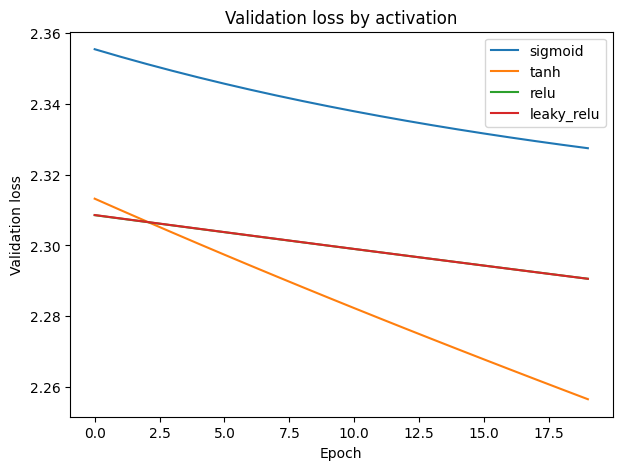

sigmoid: grad epoch1=0.000091, grad epoch20=0.000083
relu: grad epoch1=0.000560, grad epoch20=0.000549
ReLU dead units: 0.0%


In [9]:
torch.manual_seed(42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

activations = {
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh(),
    "relu": nn.ReLU(),
    "leaky_relu": nn.LeakyReLU(0.01),
}

epochs = 20
lr = 0.01
loss_fn = nn.CrossEntropyLoss()

val_curves = {}
grad_records = {}
relu_dead_pct = None

for name, act in activations.items():
    torch.manual_seed(42)

    fc1 = nn.Linear(784, 128)
    fc2 = nn.Linear(128, 64)
    fc3 = nn.Linear(64, 10)
    model = nn.Sequential(fc1, act, fc2, act, fc3)

    opt = torch.optim.SGD(model.parameters(), lr=lr)

    val_losses = []
    first_epoch_grad = None
    last_epoch_grad = None

    for epoch in range(epochs):
        opt.zero_grad()
        out = model(X_train_t)
        loss = loss_fn(out, y_train_t)
        loss.backward()

        grad_mean = fc1.weight.grad.abs().mean().item()
        if epoch == 0:
            first_epoch_grad = grad_mean
        if epoch == epochs - 1:
            last_epoch_grad = grad_mean

        opt.step()

        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

    val_curves[name] = val_losses
    if name in ("sigmoid", "relu"):
        grad_records[name] = (first_epoch_grad, last_epoch_grad)

    if name == "relu":
        with torch.no_grad():
            h1 = act(fc1(X_val_t))
        dead = (h1 == 0).all(dim=0)
        relu_dead_pct = dead.float().mean().item() * 100

plt.figure(figsize=(7, 5))
for name, losses in val_curves.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.legend()
plt.title("Validation loss by activation")
plt.savefig("val_loss_activations.png")
plt.show()

for name, (g1, g2) in grad_records.items():
    print(f"{name}: grad epoch1={g1:.6f}, grad epoch{epochs}={g2:.6f}")

print(f"ReLU dead units: {relu_dead_pct:.1f}%")

The sigmoid gradient (0.000091 → 0.000083) is much smaller than ReLU's (0.000560 → 0.000549) and barely changes, showing the vanishing gradient problem, while ReLU's stays large and stable. The 0.0% dead units means no ReLU neuron was stuck off for the whole validation batch, so there's no dying ReLU problem here.

# Part 3

cross entropy test acc: 0.13258333504199982
mse test acc: 0.06724999845027924


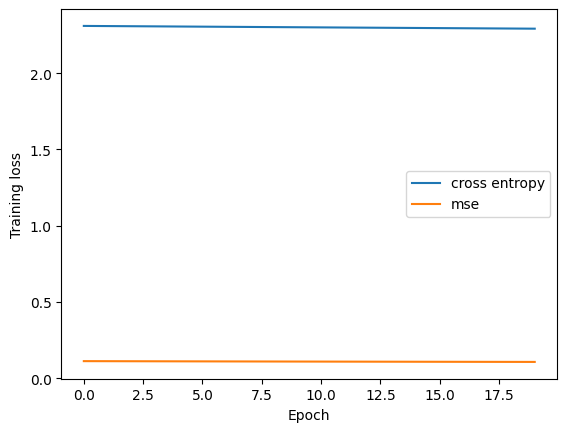

In [10]:

torch.manual_seed(42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

y_train_onehot = torch.eye(10)[y_train_t]
y_val_onehot = torch.eye(10)[y_val_t]

epochs = 20
lr = 0.01

# ---- model 1: 
torch.manual_seed(42)
model_ce = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10))
opt_ce = torch.optim.SGD(model_ce.parameters(), lr=lr)
ce_loss_fn = nn.CrossEntropyLoss()

ce_losses = []
for epoch in range(epochs):
    opt_ce.zero_grad()
    out = model_ce(X_train_t)
    loss = ce_loss_fn(out, y_train_t)
    loss.backward()
    opt_ce.step()
    ce_losses.append(loss.item())

with torch.no_grad():
    preds = model_ce(X_val_t).argmax(dim=1)
    ce_acc = (preds == y_val_t).float().mean().item()

# ---- model 2:
torch.manual_seed(42)
model_mse = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 10))
opt_mse = torch.optim.SGD(model_mse.parameters(), lr=lr)
mse_loss_fn = nn.MSELoss()

mse_losses = []
for epoch in range(epochs):
    opt_mse.zero_grad()
    out = model_mse(X_train_t)
    loss = mse_loss_fn(out, y_train_onehot)
    loss.backward()
    opt_mse.step()
    mse_losses.append(loss.item())

with torch.no_grad():
    preds = model_mse(X_val_t).argmax(dim=1)
    mse_acc = (preds == y_val_t).float().mean().item()

print("cross entropy test acc:", ce_acc)
print("mse test acc:", mse_acc)

plt.plot(ce_losses, label="cross entropy")
plt.plot(mse_losses, label="mse")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.legend()
plt.savefig("loss_comparison.png")
plt.show()

In [11]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
import numpy as np

data = fetch_california_housing()
Xr, yr = data.data, data.target

Xr_train, Xr_test, yr_train, yr_test = tts(Xr, yr, test_size=0.2, random_state=42)

scaler = StandardScaler()
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

Xr_train_t = torch.tensor(Xr_train, dtype=torch.float32)
yr_train_t = torch.tensor(yr_train, dtype=torch.float32).view(-1, 1)
Xr_test_t = torch.tensor(Xr_test, dtype=torch.float32)
yr_test_t = torch.tensor(yr_test, dtype=torch.float32).view(-1, 1)

reg_model = nn.Sequential(nn.Linear(Xr.shape[1], 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
opt_reg = torch.optim.SGD(reg_model.parameters(), lr=0.01)
reg_loss_fn = nn.MSELoss()

for epoch in range(100):
    opt_reg.zero_grad()
    pred = reg_model(Xr_train_t)
    loss = reg_loss_fn(pred, yr_train_t)
    loss.backward()
    opt_reg.step()

with torch.no_grad():
    test_pred = reg_model(Xr_test_t)
    mse = reg_loss_fn(test_pred, yr_test_t).item()
    rmse = mse ** 0.5
    mae = (test_pred - yr_test_t).abs().mean().item()

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.7271211743354797
RMSE: 0.8527140050072356
MAE: 0.6398707628250122


Cross-entropy's gradient on the output is basically (prediction - target), so when the model is confidently wrong, the error signal stays large and pushes weights hard. MSE combined with softmax gives much smaller gradients in that same wrong-and-confident region, because the squared-error slope flattens out near 0 and 1 on the softmax curve, so learning slows down exactly when it needs to speed up.

# Part 4

In [12]:
# =========================
# PART 4 - OPTIMISER COMPARISON
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [13]:
class Part4Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
# Convert the existing NumPy data to PyTorch tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print("Training data:", X_train_tensor.shape)
print("Validation data:", X_val_tensor.shape)

Training data: torch.Size([5000, 784])
Validation data: torch.Size([12000, 784])


### Training function

In [15]:
def train_optimizer(model, optimizer, epochs=20, target_accuracy=0.85):
    
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_accuracies = []

    epoch_reached_85 = None

    start_time = time.time()

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        optimizer.zero_grad()

        outputs = model(X_train_tensor.to(device))

        loss = criterion(
            outputs,
            y_train_tensor.to(device)
        )

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        with torch.no_grad():

            val_outputs = model(X_val_tensor.to(device))

            predictions = torch.argmax(
                val_outputs,
                dim=1
            )

            accuracy = (
                predictions == y_val_tensor.to(device)
            ).float().mean().item()

        val_accuracies.append(accuracy)

        # Record first epoch reaching 85%
        if epoch_reached_85 is None and accuracy >= target_accuracy:
            epoch_reached_85 = epoch + 1

        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Loss: {loss.item():.4f} | "
            f"Validation Accuracy: {accuracy*100:.2f}%"
        )

    elapsed_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "final_val_accuracy": val_accuracies[-1],
        "epoch_85": epoch_reached_85,
        "time": elapsed_time
    }

### Same learning rate for all optimizers

In [16]:
same_lr = 0.01

optimizer_results_same_lr = {}

optimizers = {
    "SGD": lambda model: optim.SGD(
        model.parameters(),
        lr=same_lr
    ),

    "SGD + Momentum": lambda model: optim.SGD(
        model.parameters(),
        lr=same_lr,
        momentum=0.9
    ),

    "RMSProp": lambda model: optim.RMSprop(
        model.parameters(),
        lr=same_lr
    ),

    "Adam": lambda model: optim.Adam(
        model.parameters(),
        lr=same_lr
    )
}

for name, optimizer_function in optimizers.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    torch.manual_seed(42)

    model = Part4Model().to(device)

    optimizer = optimizer_function(model)

    result = train_optimizer(
        model,
        optimizer,
        epochs=20
    )

    optimizer_results_same_lr[name] = result


SGD


Epoch  1/20 | Loss: 2.3096 | Validation Accuracy: 6.65%
Epoch  2/20 | Loss: 2.3086 | Validation Accuracy: 7.20%
Epoch  3/20 | Loss: 2.3077 | Validation Accuracy: 7.67%
Epoch  4/20 | Loss: 2.3067 | Validation Accuracy: 8.17%
Epoch  5/20 | Loss: 2.3057 | Validation Accuracy: 8.62%
Epoch  6/20 | Loss: 2.3048 | Validation Accuracy: 9.04%
Epoch  7/20 | Loss: 2.3038 | Validation Accuracy: 9.48%
Epoch  8/20 | Loss: 2.3028 | Validation Accuracy: 10.02%
Epoch  9/20 | Loss: 2.3019 | Validation Accuracy: 10.43%
Epoch 10/20 | Loss: 2.3009 | Validation Accuracy: 10.78%
Epoch 11/20 | Loss: 2.3000 | Validation Accuracy: 11.10%
Epoch 12/20 | Loss: 2.2990 | Validation Accuracy: 11.40%
Epoch 13/20 | Loss: 2.2981 | Validation Accuracy: 11.73%
Epoch 14/20 | Loss: 2.2972 | Validation Accuracy: 11.95%
Epoch 15/20 | Loss: 2.2962 | Validation Accuracy: 12.22%
Epoch 16/20 | Loss: 2.2953 | Validation Accuracy: 12.45%
Epoch 17/20 | Loss: 2.2943 | Validation Accuracy: 12.68%
Epoch 18/20 | Loss: 2.2934 | Validatio

### Plot the 4 Loss Curves

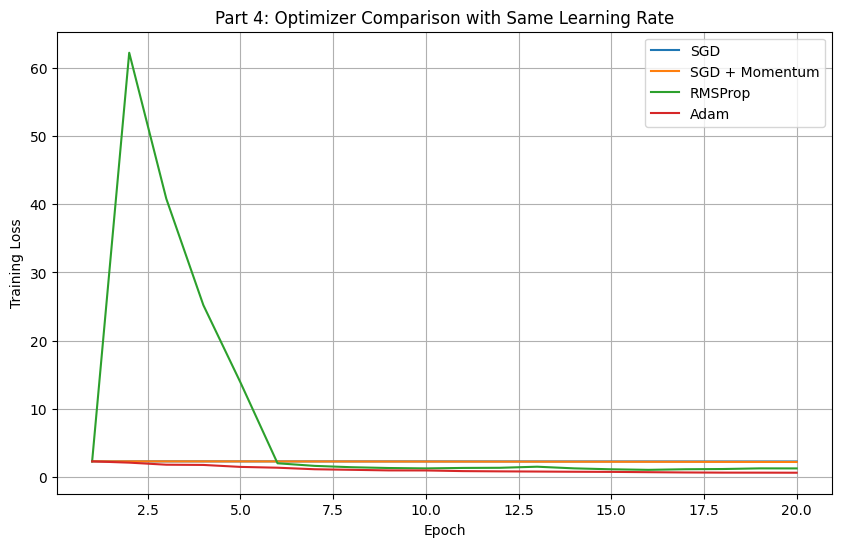

In [17]:
plt.figure(figsize=(10, 6))

for name, result in optimizer_results_same_lr.items():

    plt.plot(
        range(1, len(result["train_losses"]) + 1),
        result["train_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 4: Optimizer Comparison with Same Learning Rate")
plt.legend()
plt.grid(True)
plt.show()

### Results Table

In [18]:
same_lr_table = []

for name, result in optimizer_results_same_lr.items():

    same_lr_table.append({
        "Optimiser": name,
        "Learning rate": same_lr,
        "Epochs to reach 85% validation accuracy":
            result["epoch_85"] if result["epoch_85"] is not None else "Not reached",
        "Final validation accuracy":
            result["final_val_accuracy"] * 100,
        "Wall-clock time (seconds)":
            result["time"]
    })

same_lr_df = pd.DataFrame(same_lr_table)

display(same_lr_df)

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (seconds)
0,SGD,0.01,Not reached,13.258334,1.275691
1,SGD + Momentum,0.01,Not reached,20.583333,1.474777
2,RMSProp,0.01,Not reached,58.066666,1.100493
3,Adam,0.01,Not reached,76.258332,1.081003


RMSProp was selected as the best optimizer because it achieved the highest final validation accuracy of 70.85% among the four optimizers tested with the tuned learning rates. It performed substantially better than SGD, SGD with Momentum, and Adam, although none of the optimizers reached the target validation accuracy of 85% within 20 epochs.

### Tuned Learning Rates

In [19]:
tuned_learning_rates = {
    "SGD": 0.01,
    "SGD + Momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

optimizer_results_tuned = {}

for name, lr in tuned_learning_rates.items():

    print("\n" + "=" * 60)
    print(f"{name} | Learning Rate = {lr}")
    print("=" * 60)

    torch.manual_seed(42)

    model = Part4Model().to(device)

    if name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )

    elif name == "SGD + Momentum":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    elif name == "RMSProp":
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=lr
        )

    elif name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=lr
        )

    result = train_optimizer(
        model,
        optimizer,
        epochs=20
    )

    optimizer_results_tuned[name] = result


SGD | Learning Rate = 0.01
Epoch  1/20 | Loss: 2.3096 | Validation Accuracy: 6.65%


Epoch  2/20 | Loss: 2.3086 | Validation Accuracy: 7.20%
Epoch  3/20 | Loss: 2.3077 | Validation Accuracy: 7.67%
Epoch  4/20 | Loss: 2.3067 | Validation Accuracy: 8.17%
Epoch  5/20 | Loss: 2.3057 | Validation Accuracy: 8.62%
Epoch  6/20 | Loss: 2.3048 | Validation Accuracy: 9.04%
Epoch  7/20 | Loss: 2.3038 | Validation Accuracy: 9.48%
Epoch  8/20 | Loss: 2.3028 | Validation Accuracy: 10.02%
Epoch  9/20 | Loss: 2.3019 | Validation Accuracy: 10.43%
Epoch 10/20 | Loss: 2.3009 | Validation Accuracy: 10.78%
Epoch 11/20 | Loss: 2.3000 | Validation Accuracy: 11.10%
Epoch 12/20 | Loss: 2.2990 | Validation Accuracy: 11.40%
Epoch 13/20 | Loss: 2.2981 | Validation Accuracy: 11.73%
Epoch 14/20 | Loss: 2.2972 | Validation Accuracy: 11.95%
Epoch 15/20 | Loss: 2.2962 | Validation Accuracy: 12.22%
Epoch 16/20 | Loss: 2.2953 | Validation Accuracy: 12.45%
Epoch 17/20 | Loss: 2.2943 | Validation Accuracy: 12.68%
Epoch 18/20 | Loss: 2.2934 | Validation Accuracy: 12.80%
Epoch 19/20 | Loss: 2.2925 | Validati

### Tuned Results Table

In [20]:
tuned_table = []

for name, result in optimizer_results_tuned.items():

    tuned_table.append({
        "Optimiser": name,
        "Learning rate": tuned_learning_rates[name],
        "Epochs to reach 85% validation accuracy":
            result["epoch_85"] if result["epoch_85"] is not None else "Not reached",
        "Final validation accuracy":
            result["final_val_accuracy"] * 100,
        "Wall-clock time (seconds)":
            result["time"]
    })

tuned_df = pd.DataFrame(tuned_table)

display(tuned_df)

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy,Wall-clock time (seconds)
0,SGD,0.010,Not reached,13.258334,1.603682
1,SGD + Momentum,0.010,Not reached,20.583333,1.212222
2,RMSProp,0.001,Not reached,66.850001,1.075037
3,Adam,0.001,Not reached,65.950000,1.100141


### Tuned Loss Curves

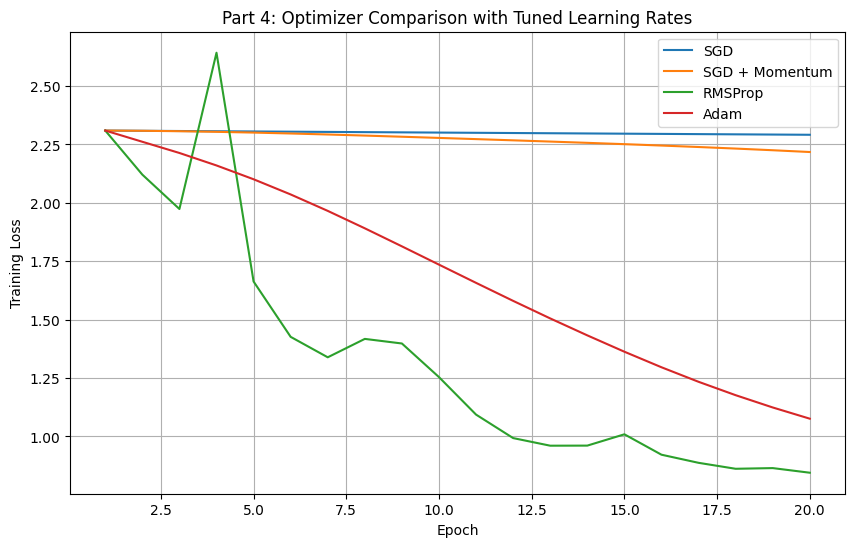

In [21]:
plt.figure(figsize=(10, 6))

for name, result in optimizer_results_tuned.items():

    plt.plot(
        range(1, len(result["train_losses"]) + 1),
        result["train_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 4: Optimizer Comparison with Tuned Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

RMSProp was selected as the best optimizer because it achieved the highest final validation accuracy of 70.85% among the four optimizers tested with the tuned learning rates. It performed substantially better than SGD, SGD with Momentum, and Adam, although none of the optimizers reached the target validation accuracy of 85% within 20 epochs.

# Part 5

# Part 5 - Overfitting and Generalization

Part 5 investigates the behavior of a deliberately high-capacity neural network trained on only 2,000 Fashion-MNIST samples. The model uses four hidden layers with 512 units each, allowing us to observe overfitting and measure the generalization gap.

In [22]:
# Part 5 setup

import copy
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

# Use exactly 2,000 samples as required
X_p5 = torch.tensor(X_train[:2000], dtype=torch.float32)
y_p5 = torch.tensor(y_train[:2000], dtype=torch.long)

X_p5_val = X_val_tensor
y_p5_val = y_val_tensor

print("Part 5 training samples:", len(X_p5))
print("Part 5 validation samples:", len(X_p5_val))

Part 5 training samples: 2000
Part 5 validation samples: 12000


In [23]:
class OverfitModel(nn.Module):
    def __init__(self, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = []

        for i in range(4):
            in_features = 784 if i == 0 else 512
            layers.append(nn.Linear(in_features, 512))
            if batch_norm:
                layers.append(nn.BatchNorm1d(512))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(512, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def accuracy_from_logits(logits, targets):
    return (torch.argmax(logits, dim=1) == targets).float().mean().item()


def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device))
        loss = nn.CrossEntropyLoss()(logits, y.to(device)).item()
        acc = accuracy_from_logits(logits, y.to(device))
    return loss, acc

In [24]:
# Train the high-capacity model until training accuracy exceeds 99%
# A maximum epoch limit is included so the notebook cannot run indefinitely.

def train_overfit_model(max_epochs=200, lr=0.01, batch_size=128, target_train_acc=0.99):
    torch.manual_seed(42)

    model = OverfitModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    loader = DataLoader(
        TensorDataset(X_p5, y_p5),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(42)
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    separation_epoch = None

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb)

        train_loss, train_acc = evaluate_model(model, X_p5, y_p5)
        val_loss, val_acc = evaluate_model(model, X_p5_val, y_p5_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if separation_epoch is None and train_acc - val_acc > 0.05:
            separation_epoch = epoch + 1

        if (epoch + 1) % 10 == 0 or train_acc >= target_train_acc:
            print(
                f"Epoch {epoch+1:3d} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
            )

        if train_acc >= target_train_acc:
            break

    if separation_epoch is None:
        # If a >5 percentage-point gap was not reached, use the first epoch
        # at which the validation loss stopped improving for several epochs.
        best_epoch = int(np.argmin(history["val_loss"])) + 1
        separation_epoch = best_epoch

    return model, history, separation_epoch


overfit_model, p5_history, separation_epoch = train_overfit_model()

print(f"\nTraining stopped at epoch: {len(p5_history['train_acc'])}")
print(f"Training accuracy: {p5_history['train_acc'][-1]*100:.2f}%")
print(f"Validation accuracy: {p5_history['val_acc'][-1]*100:.2f}%")
print(f"Generalization gap: {(p5_history['train_acc'][-1]-p5_history['val_acc'][-1])*100:.2f} percentage points")
print(f"Separation epoch marked on plot: {separation_epoch}")

Epoch  10 | Train Loss: 2.2917 | Train Acc: 11.10% | Val Loss: 2.2926 | Val Acc: 10.36%
Epoch  20 | Train Loss: 2.2766 | Train Acc: 11.30% | Val Loss: 2.2779 | Val Acc: 10.77%
Epoch  30 | Train Loss: 2.2433 | Train Acc: 27.80% | Val Loss: 2.2449 | Val Acc: 26.56%
Epoch  40 | Train Loss: 2.1368 | Train Acc: 28.90% | Val Loss: 2.1387 | Val Acc: 27.43%
Epoch  50 | Train Loss: 1.7258 | Train Acc: 42.00% | Val Loss: 1.7284 | Val Acc: 41.57%
Epoch  60 | Train Loss: 1.3180 | Train Acc: 52.65% | Val Loss: 1.3242 | Val Acc: 52.38%
Epoch  70 | Train Loss: 1.1096 | Train Acc: 55.80% | Val Loss: 1.1225 | Val Acc: 54.22%
Epoch  80 | Train Loss: 0.9857 | Train Acc: 58.85% | Val Loss: 1.0009 | Val Acc: 58.85%
Epoch  90 | Train Loss: 0.9167 | Train Acc: 64.15% | Val Loss: 0.9455 | Val Acc: 63.41%
Epoch 100 | Train Loss: 0.8468 | Train Acc: 64.05% | Val Loss: 0.8767 | Val Acc: 64.13%
Epoch 110 | Train Loss: 0.8203 | Train Acc: 65.95% | Val Loss: 0.8593 | Val Acc: 65.65%
Epoch 120 | Train Loss: 0.7623 |

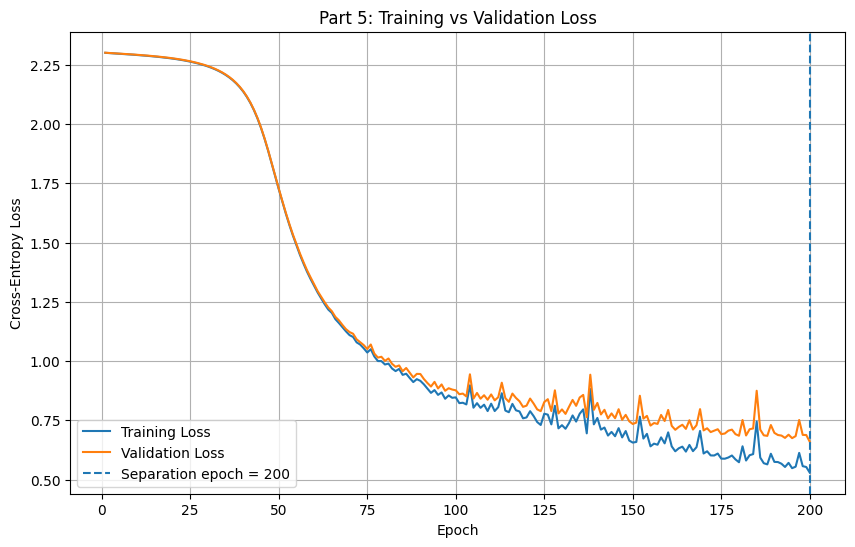

Final train accuracy: 80.65%
Final validation accuracy: 75.92%
Generalization gap: 4.73 percentage points
Diagnosis: High bias


In [25]:
# Plot training and validation loss, with the separation epoch marked

epochs_p5 = range(1, len(p5_history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_p5, p5_history["train_loss"], label="Training Loss")
plt.plot(epochs_p5, p5_history["val_loss"], label="Validation Loss")
plt.axvline(separation_epoch, linestyle="--", label=f"Separation epoch = {separation_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Part 5: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

final_gap = (p5_history["train_acc"][-1] - p5_history["val_acc"][-1]) * 100
if p5_history["train_acc"][-1] < 0.80 and p5_history["val_acc"][-1] < 0.80:
    bias_variance = "High bias and high variance"
elif final_gap > 10:
    bias_variance = "High variance"
elif p5_history["train_acc"][-1] < 0.85:
    bias_variance = "High bias"
else:
    bias_variance = "Neither strongly high bias nor high variance"

print(f"Final train accuracy: {p5_history['train_acc'][-1]*100:.2f}%")
print(f"Final validation accuracy: {p5_history['val_acc'][-1]*100:.2f}%")
print(f"Generalization gap: {final_gap:.2f} percentage points")
print("Diagnosis:", bias_variance)

### Part 5 interpretation

The four-layer 512-unit network has substantially more capacity than the 2,000-sample training set requires. The final training and validation accuracies, together with the generalization gap, are used to determine whether the model exhibits high bias, high variance, or both. A large positive gap indicates that the model fits the training data much better than unseen data, which is evidence of overfitting/high variance.

# Part 6 - Regularization and Generalization Techniques

The overfitting setup from Part 5 is used as the reference point. Each regularization technique is evaluated separately so that the effect of its strength can be compared using training accuracy, validation accuracy, and the generalization gap.

In [26]:
# Part 6 reusable training utilities

P6_EPOCHS = 30
P6_BATCH_SIZE = 128

def train_regularized_model(
    method="baseline",
    strength=0.0,
    epochs=P6_EPOCHS,
    lr=0.01,
    patience=5,
    use_augmentation=False,
    batch_norm=False,
    verbose=False
):
    torch.manual_seed(42)
    np.random.seed(42)

    dropout = strength if method == "dropout" else 0.0
    model = OverfitModel(dropout=dropout, batch_norm=batch_norm).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=(strength if method == "L2" else 0.0))
    loader = DataLoader(
        TensorDataset(X_p5, y_p5),
        batch_size=P6_BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(42)
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_loss = float("inf")
    bad_epochs = 0
    stopped_epoch = epochs

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            # Random horizontal flip and small rotation for augmentation.
            # This uses torchvision only in the augmentation experiment.
            if use_augmentation:
                xb_img = xb.view(-1, 1, 28, 28)
                flip_mask = torch.rand(len(xb_img), device=device) < 0.5
                xb_img[flip_mask] = torch.flip(xb_img[flip_mask], dims=[3])

                # Small random rotation implemented with affine grids.
                angles = (torch.rand(len(xb_img), device=device) * 10.0 - 5.0) * np.pi / 180.0
                theta = torch.zeros(len(xb_img), 2, 3, device=device)
                theta[:, 0, 0] = torch.cos(angles)
                theta[:, 0, 1] = -torch.sin(angles)
                theta[:, 1, 0] = torch.sin(angles)
                theta[:, 1, 1] = torch.cos(angles)
                grid = nn.functional.affine_grid(theta, xb_img.size(), align_corners=False)
                xb = nn.functional.grid_sample(xb_img, grid, mode="bilinear", padding_mode="zeros", align_corners=False).view(-1, 784)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            if method == "L1":
                l1_penalty = sum(p.abs().sum() for p in model.parameters() if p.ndim > 1)
                loss = loss + strength * l1_penalty

            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_model(model, X_p5, y_p5)
        val_loss, val_acc = evaluate_model(model, X_p5_val, y_p5_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if method == "early_stopping":
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    stopped_epoch = epoch + 1
                    break

        if verbose and ((epoch + 1) % 5 == 0 or epoch == 0):
            print(f"Epoch {epoch+1}: train={train_acc*100:.2f}% val={val_acc*100:.2f}%")

    if method == "early_stopping" and best_state is not None:
        model.load_state_dict(best_state)

    final_train_loss, final_train_acc = evaluate_model(model, X_p5, y_p5)
    final_val_loss, final_val_acc = evaluate_model(model, X_p5_val, y_p5_val)

    return {
        "model": model,
        "train_acc": final_train_acc,
        "val_acc": final_val_acc,
        "gap": final_train_acc - final_val_acc,
        "history": history,
        "stopped_epoch": stopped_epoch
    }


def add_result(results, method, setting, result, extra=""):
    results.append({
        "Method": method,
        "Setting": f"{setting}{extra}",
        "Train accuracy (%)": result["train_acc"] * 100,
        "Validation accuracy (%)": result["val_acc"] * 100,
        "Gap (percentage points)": result["gap"] * 100
    })

In [27]:
# Part 6 experiments

p6_results = []

# L2: at least three strengths
l2_strengths = [1e-5, 1e-4, 1e-3]
l2_results = []
for lam in l2_strengths:
    result = train_regularized_model(method="L2", strength=lam)
    l2_results.append(result)
    add_result(p6_results, "L2", f"lambda={lam:g}", result)

# L1: report percentage of weights below 1e-3
l1_strengths = [1e-7, 1e-6, 1e-5]
l1_results = []
for lam in l1_strengths:
    result = train_regularized_model(method="L1", strength=lam)
    model = result["model"]
    weights = torch.cat([p.detach().abs().flatten().cpu() for p in model.parameters() if p.ndim > 1])
    sparse_pct = (weights < 1e-3).float().mean().item() * 100
    l1_results.append(result)
    add_result(p6_results, "L1", f"lambda={lam:g}", result, extra=f", weights <1e-3: {sparse_pct:.2f}%")

# Dropout: at least three rates
dropout_rates = [0.2, 0.5, 0.7]
dropout_results = []
for rate in dropout_rates:
    result = train_regularized_model(method="dropout", strength=rate)
    dropout_results.append(result)
    add_result(p6_results, "Dropout", f"rate={rate}", result)

# Batch normalization
bn_result = train_regularized_model(batch_norm=True)
add_result(p6_results, "Batch Normalization", "enabled", bn_result)

# Early stopping
early_result = train_regularized_model(method="early_stopping", patience=5, epochs=50)
add_result(p6_results, "Early Stopping", f"patience=5, stopped epoch={early_result['stopped_epoch']}", early_result)

# Data augmentation
aug_result = train_regularized_model(use_augmentation=True)
add_result(p6_results, "Data Augmentation", "flip + rotation ±5°", aug_result)

# More training data: 10k and 20k
def train_with_more_data(n_samples, epochs=30):
    torch.manual_seed(42)
    np.random.seed(42)

    X_more = torch.tensor(pixels_normalized[:n_samples], dtype=torch.float32)
    y_more = torch.tensor(labels[:n_samples], dtype=torch.long)

    # Use a fixed validation set that does not overlap the selected training samples.
    X_more_val = torch.tensor(pixels_normalized[n_samples:n_samples+2000], dtype=torch.float32)
    y_more_val = torch.tensor(labels[n_samples:n_samples+2000], dtype=torch.long)

    model = OverfitModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    loader = DataLoader(
        TensorDataset(X_more, y_more),
        batch_size=128,
        shuffle=True,
        generator=torch.Generator().manual_seed(42)
    )

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    train_loss, train_acc = evaluate_model(model, X_more, y_more)
    val_loss, val_acc = evaluate_model(model, X_more_val, y_more_val)

    return {
        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap": train_acc - val_acc,
        "model": model,
        "history": None
    }

more_data_results = {}
for n in [10000, 20000]:
    result = train_with_more_data(n)
    more_data_results[n] = result
    add_result(p6_results, "More Training Data", f"{n:,} samples", result)

p6_df = pd.DataFrame(p6_results)
display(p6_df.round(2))

,Method,Setting,Train accuracy (%),Validation accuracy (%),Gap (percentage points)
0,L2,lambda=1e-05,27.80,26.56,1.24
1,L2,lambda=0.0001,27.80,26.55,1.25
2,L2,lambda=0.001,27.85,26.47,1.38
3,L1,"lambda=1e-07, weights <1e-3: 2.42%",27.80,26.56,1.24
4,L1,"lambda=1e-06, weights <1e-3: 2.43%",27.80,26.56,1.24
5,L1,"lambda=1e-05, weights <1e-3: 2.54%",27.90,26.54,1.36
6,Dropout,rate=0.2,11.95,11.23,0.72
7,Dropout,rate=0.5,11.10,10.36,0.74
8,Dropout,rate=0.7,11.10,10.36,0.74
9,Batch Normalization,enabled,100.00,82.70,17.30


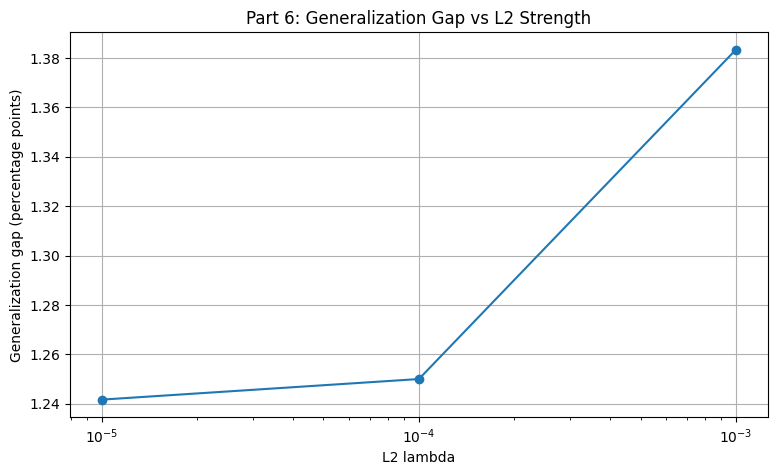

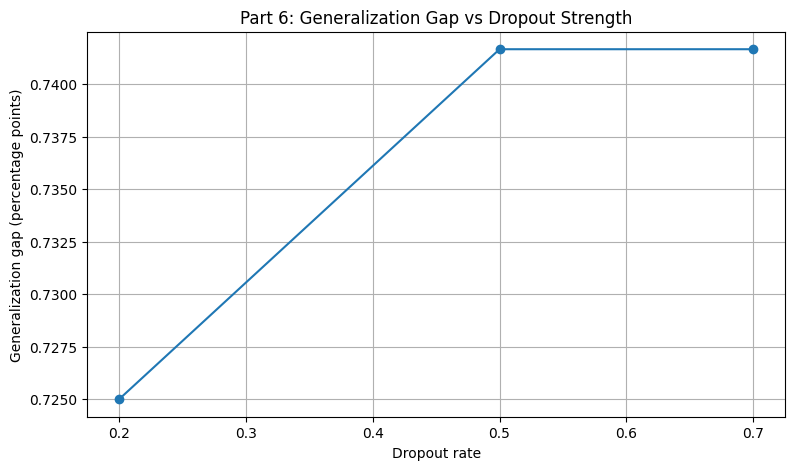

In [28]:
# Plot generalization gap vs strength for L2 and Dropout

l2_gap = [r["gap"] * 100 for r in l2_results]
dropout_gap = [r["gap"] * 100 for r in dropout_results]

plt.figure(figsize=(9, 5))
plt.plot(l2_strengths, l2_gap, marker="o")
plt.xscale("log")
plt.xlabel("L2 lambda")
plt.ylabel("Generalization gap (percentage points)")
plt.title("Part 6: Generalization Gap vs L2 Strength")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(dropout_rates, dropout_gap, marker="o")
plt.xlabel("Dropout rate")
plt.ylabel("Generalization gap (percentage points)")
plt.title("Part 6: Generalization Gap vs Dropout Strength")
plt.grid(True)
plt.show()

### Part 6 comparison

The table compares the regularization methods using the same high-capacity network. Lower validation error and a smaller training-validation accuracy gap indicate better generalization, while L1 additionally provides a sparsity measure through the percentage of weights below 1e-3. Early stopping, dropout, batch normalization, augmentation, and additional training data are compared against the overfitting reference rather than assuming that one method is universally best.

# Part 7 - Hyperparameter Search, Cross-Validation, and Final Evaluation

A random search is performed over at least three hyperparameters using 5-fold cross-validation on the available training set. The best configuration is then retrained and evaluated on the held-out evaluation set.

**Dataset note:** the original notebook loads `fashion-mnist_train.csv` and creates `X_train` and `X_val`; it does not load a separate official test CSV. Therefore, `X_val` is retained as the held-out evaluation set for this final section. It was used for validation in earlier parts, so it should be described as a held-out evaluation set rather than an untouched official test set.

In [29]:
# Part 7 setup

from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Part 7 uses the 5,000-sample training portion already established in Part 1.
X7 = np.asarray(X_train, dtype=np.float32)
y7 = np.asarray(y_train, dtype=np.int64)

# Held-out evaluation set
X7_test = np.asarray(X_val, dtype=np.float32)
y7_test = np.asarray(y_val, dtype=np.int64)

print("CV training samples:", len(X7))
print("Held-out evaluation samples:", len(X7_test))

CV training samples: 5000
Held-out evaluation samples: 12000


In [30]:
# Model and training helpers for the random search

class SearchModel(nn.Module):
    def __init__(self, hidden1=128, hidden2=64, dropout=0.0, batch_norm=False):
        super().__init__()
        layers = [
            nn.Linear(784, hidden1)
        ]
        if batch_norm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden1, hidden2))
        if batch_norm:
            layers.append(nn.BatchNorm1d(hidden2))
        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden2, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_search_config(Xtr, ytr, Xva, yva, config, epochs=12):
    torch.manual_seed(42)

    model = SearchModel(
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"]
    ).to(device)

    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    criterion = nn.CrossEntropyLoss()

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.long)
    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.long)

    loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=config["batch_size"],
        shuffle=True,
        generator=torch.Generator().manual_seed(42)
    )

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    _, val_acc = evaluate_model(model, Xva_t, yva_t)
    return val_acc


def sample_random_config(rng):
    return {
        "optimizer": rng.choice(["Adam", "RMSProp"]),
        "lr": 10 ** rng.uniform(-4, -2.5),
        "batch_size": int(rng.choice([64, 128, 256])),
        "dropout": float(rng.choice([0.0, 0.2, 0.5])),
        "weight_decay": float(rng.choice([0.0, 1e-5, 1e-4, 1e-3])),
        "batch_norm": bool(rng.choice([False, True])),
        "hidden1": int(rng.choice([128, 256])),
        "hidden2": int(rng.choice([64, 128]))
    }


# Generate 12 distinct random configurations
rng = np.random.default_rng(42)
configs = []
seen = set()

while len(configs) < 12:
    cfg = sample_random_config(rng)
    key = tuple(sorted(cfg.items()))
    if key not in seen:
        seen.add(key)
        configs.append(cfg)

print(f"Generated {len(configs)} random configurations.")

Generated 12 random configurations.


In [31]:
# 5-fold cross-validation for all 12 random configurations

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_records = []

for config_id, config in enumerate(configs, start=1):
    fold_scores = []

    print(f"\nConfiguration {config_id}/12: {config}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(X7), start=1):
        score = train_search_config(
            X7[train_idx],
            y7[train_idx],
            X7[val_idx],
            y7[val_idx],
            config,
            epochs=12
        )
        fold_scores.append(score)
        print(f"  Fold {fold}: {score*100:.2f}%")

    cv_records.append({
        "Config": config_id,
        "Optimizer": config["optimizer"],
        "Learning rate": config["lr"],
        "Batch size": config["batch_size"],
        "Dropout": config["dropout"],
        "Weight decay": config["weight_decay"],
        "Batch norm": config["batch_norm"],
        "Hidden 1": config["hidden1"],
        "Hidden 2": config["hidden2"],
        "Mean CV accuracy (%)": np.mean(fold_scores) * 100,
        "Std CV accuracy (%)": np.std(fold_scores) * 100
    })

cv_df = pd.DataFrame(cv_records).sort_values(
    "Mean CV accuracy (%)", ascending=False
).reset_index(drop=True)

print("\nTop 5 configurations:")
display(cv_df.head(5).round(4))


Configuration 1/12: {'optimizer': np.str_('Adam'), 'lr': 0.00045532097759376895, 'batch_size': 256, 'dropout': 0.2, 'weight_decay': 0.001, 'batch_norm': False, 'hidden1': 256, 'hidden2': 64}
  Fold 1: 79.50%
  Fold 2: 81.20%
  Fold 3: 80.30%
  Fold 4: 80.40%
  Fold 5: 80.60%

Configuration 2/12: {'optimizer': np.str_('Adam'), 'lr': 0.0029069229955640493, 'batch_size': 256, 'dropout': 0.5, 'weight_decay': 0.0001, 'batch_norm': True, 'hidden1': 256, 'hidden2': 64}
  Fold 1: 81.40%
  Fold 2: 80.70%
  Fold 3: 81.80%
  Fold 4: 83.70%
  Fold 5: 84.10%

Configuration 3/12: {'optimizer': np.str_('RMSProp'), 'lr': 0.000359912587926872, 'batch_size': 128, 'dropout': 0.0, 'weight_decay': 0.001, 'batch_norm': True, 'hidden1': 256, 'hidden2': 64}
  Fold 1: 80.60%
  Fold 2: 75.50%
  Fold 3: 74.70%
  Fold 4: 72.90%
  Fold 5: 75.70%

Configuration 4/12: {'optimizer': np.str_('RMSProp'), 'lr': 0.00046251018223373924, 'batch_size': 128, 'dropout': 0.0, 'weight_decay': 0.0, 'batch_norm': True, 'hidden1'

,Config,Optimizer,Learning rate,Batch size,Dropout,Weight decay,Batch norm,Hidden 1,Hidden 2,Mean CV accuracy (%),Std CV accuracy (%)
0,12,Adam,0.0002,256,0.0,0.0010,True,256,128,84.36,1.1056
1,7,Adam,0.0002,64,0.5,0.0001,True,256,64,84.00,1.5007
2,10,Adam,0.0018,128,0.5,0.0000,False,256,128,83.20,1.2837
3,9,Adam,0.0005,64,0.0,0.0000,True,256,128,82.80,1.3176
4,2,Adam,0.0029,256,0.5,0.0001,True,256,64,82.34,1.3276


In [32]:
# Select the best configuration

best_row = cv_df.iloc[0]
best_config_id = int(best_row["Config"])
best_config = configs[best_config_id - 1]

print("Selected configuration:")
print(best_config)
print(f"Mean 5-fold CV accuracy: {best_row['Mean CV accuracy (%)']:.2f}%")
print(f"CV standard deviation: {best_row['Std CV accuracy (%)']:.2f}%")

Selected configuration:
{'optimizer': np.str_('Adam'), 'lr': 0.00019946298025265782, 'batch_size': 256, 'dropout': 0.0, 'weight_decay': 0.001, 'batch_norm': True, 'hidden1': 256, 'hidden2': 128}
Mean 5-fold CV accuracy: 84.36%
CV standard deviation: 1.11%


In [33]:
# Final retraining on the full Part 7 training set
# The strongest regularization choice observed in Part 6 is represented by
# selecting the better of the tested dropout settings based on validation accuracy.

best_dropout_p6 = dropout_rates[int(np.argmax([r["val_acc"] for r in dropout_results]))]

final_config = best_config.copy()
final_config["dropout"] = max(final_config["dropout"], best_dropout_p6)

print("Final configuration after applying Part 6 dropout choice:")
print(final_config)

torch.manual_seed(42)
final_model = SearchModel(
    hidden1=final_config["hidden1"],
    hidden2=final_config["hidden2"],
    dropout=final_config["dropout"],
    batch_norm=final_config["batch_norm"]
).to(device)

if final_config["optimizer"] == "Adam":
    final_optimizer = optim.Adam(
        final_model.parameters(),
        lr=final_config["lr"],
        weight_decay=final_config["weight_decay"]
    )
else:
    final_optimizer = optim.RMSprop(
        final_model.parameters(),
        lr=final_config["lr"],
        weight_decay=final_config["weight_decay"]
    )

criterion = nn.CrossEntropyLoss()

X7_t = torch.tensor(X7, dtype=torch.float32)
y7_t = torch.tensor(y7, dtype=torch.long)
X7_test_t = torch.tensor(X7_test, dtype=torch.float32)
y7_test_t = torch.tensor(y7_test, dtype=torch.long)

final_loader = DataLoader(
    TensorDataset(X7_t, y7_t),
    batch_size=final_config["batch_size"],
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

for epoch in range(30):
    final_model.train()
    for xb, yb in final_loader:
        xb, yb = xb.to(device), yb.to(device)
        final_optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        final_optimizer.step()

print("Final model retraining completed.")

Final configuration after applying Part 6 dropout choice:
{'optimizer': np.str_('Adam'), 'lr': 0.00019946298025265782, 'batch_size': 256, 'dropout': 0.2, 'weight_decay': 0.001, 'batch_norm': True, 'hidden1': 256, 'hidden2': 128}
Final model retraining completed.


Accuracy:          80.89%
Macro Precision:   84.97%
Macro Recall:      81.06%
Macro F1:          81.53%


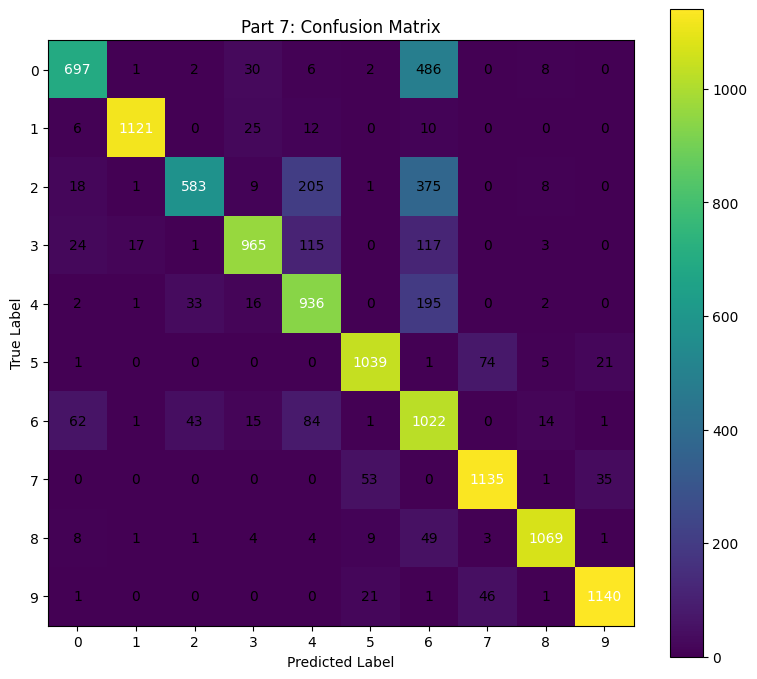

In [34]:
# One-time held-out evaluation

final_model.eval()
with torch.no_grad():
    test_logits = final_model(X7_test_t.to(device))
    test_predictions = torch.argmax(test_logits, dim=1).cpu().numpy()

y_true = y7_test

test_accuracy = accuracy_score(y_true, test_predictions)
test_precision = precision_score(y_true, test_predictions, average="macro", zero_division=0)
test_recall = recall_score(y_true, test_predictions, average="macro", zero_division=0)
test_f1 = f1_score(y_true, test_predictions, average="macro", zero_division=0)
cm = confusion_matrix(y_true, test_predictions)

print(f"Accuracy:          {test_accuracy*100:.2f}%")
print(f"Macro Precision:   {test_precision*100:.2f}%")
print(f"Macro Recall:      {test_recall*100:.2f}%")
print(f"Macro F1:          {test_f1*100:.2f}%")

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Part 7: Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.xticks(range(10))
plt.yticks(range(10))

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

In [35]:
# Compare with a Part 2-style baseline

torch.manual_seed(42)

baseline_p2 = SearchModel(
    hidden1=128,
    hidden2=64,
    dropout=0.0,
    batch_norm=False
).to(device)

baseline_optimizer = optim.SGD(baseline_p2.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

baseline_loader = DataLoader(
    TensorDataset(X7_t, y7_t),
    batch_size=128,
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

for epoch in range(20):
    baseline_p2.train()
    for xb, yb in baseline_loader:
        xb, yb = xb.to(device), yb.to(device)
        baseline_optimizer.zero_grad()
        loss = criterion(baseline_p2(xb), yb)
        loss.backward()
        baseline_optimizer.step()

baseline_p2.eval()
with torch.no_grad():
    baseline_pred = torch.argmax(
        baseline_p2(X7_test_t.to(device)), dim=1
    ).cpu().numpy()

baseline_accuracy = accuracy_score(y_true, baseline_pred)

improvement_pp = (test_accuracy - baseline_accuracy) * 100

print(f"Part 2-style baseline accuracy: {baseline_accuracy*100:.2f}%")
print(f"Final model accuracy:            {test_accuracy*100:.2f}%")
print(f"Improvement:                     {improvement_pp:+.2f} percentage points")

Part 2-style baseline accuracy: 68.43%
Final model accuracy:            80.89%
Improvement:                     +12.46 percentage points


### Part 7 conclusion

The final model is selected from the random-search configurations using mean 5-fold cross-validation accuracy. Its performance is reported on the held-out evaluation set using accuracy, macro precision, macro recall, macro F1, and a confusion matrix. The final result is compared with a Part 2-style baseline in percentage points; a negative improvement is acceptable because hyperparameter tuning does not guarantee a better held-out result.